# Sistema de Recuperação de Imagens por Conteúdo (CBIR) com Bag of Visual Words

## Sobre o Projeto

Este projeto consiste em um pipeline completo de Visão Computacional com o objetivo de implementar um sistema de Recuperação de Imagens Baseada em Conteúdo (Content-Based Image Retrieval - CBIR).

A solução utiliza a abordagem **Bag of Visual Words (BoVW)** para representar imagens por meio de descritores visuais locais e recuperar automaticamente imagens semelhantes a partir de uma consulta.

O projeto demonstra conceitos fundamentais de Visão Computacional, Recuperação de Informação e Machine Learning não supervisionado.

## Objetivo

Construir um pipeline de CBIR baseada em BoVW, utilizando keypoints locais (SIFT), clustering com KMeans e histograma de palavras visuais para comparar e recuperar imagens semelhantes.

**Etapas do processo:**

- Extrair características locais das imagens;
- Construir um vocabulário visual utilizando clusterização;
- Representar imagens através de histogramas visuais;
- Calcular similaridade entre imagens;
- Recuperar automaticamente imagens semelhantes.

## Dataset

O projeto utiliza o dataset **Columbia Object Image Library (COIL-100)** existente na plataforma do Kaggle Inc, mais precisamente em https://www.kaggle.com/datasets/jessicali9530/coil100 . 

O conjunto de dados COIL-100 foi coletado pelo Centro de Pesquisa em Sistemas Inteligentes do Departamento de Ciência da Computação da Universidade de Columbia.

O banco de dados contém imagens coloridas de 100 objetos. 

Os objetos foram colocados em uma plataforma giratória motorizada contra um fundo preto e as imagens foram capturadas em ângulos internos de 5 graus.

Este conjunto de dados foi utilizado em um sistema de reconhecimento de objetos em tempo real, no qual um sensor do sistema identificava o objeto e exibia sua posição angular.

**Detalhes do dataset**

* Há 7.200 imagens de 100 objetos. Cada objeto foi girado em um suporte giratório de 360 graus para variar sua pose em relação a uma câmera colorida fixa.

* As imagens dos objetos foram capturadas em intervalos de 5 graus entre as poses.Isso corresponde a 72 poses por objeto.

* Em seguida, as imagens foram normalizadas em tamanho.

* Os objetos apresentam uma grande variedade de características geométricas e de refletância complexas.

# 0.0 Imports

In [1]:
from glob import glob
import cv2
import numpy as np
import matplotlib.pyplot as plt
import re
import os
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import cosine_similarity

# **1. Extração de Características Locais**

## Leitura da base de dados

In [2]:
PATH_DIR = "coil-100/"

# Garantir que o caminho termina com barra
if not PATH_DIR.endswith('/') and not PATH_DIR.endswith('\\'):
    PATH_DIR += '/'

# Obter lista completa de caminhos das imagens
images_path = sorted(glob(f"{PATH_DIR}*.png"))

if len(images_path) == 0:
    # Tentar com extensão .jpg
    images_path = sorted(glob(f"{PATH_DIR}*.jpg"))

print(f"Total de {len(images_path)} imagens encontradas.")

# Extrair APENAS o nome do arquivo (sem o caminho)
images_name = [os.path.basename(path) for path in images_path]

# Mostrar alguns exemplos
print(f"Exemplos de nomes: {images_name[:3]}")

# Extrair IDs dos objetos (padrão COIL: objX__Y.png)
objs = sorted(set([name.split('__')[0] for name in images_name]))
print(f"Total de {len(objs)} objetos")
print(f"Objetos: {objs[:5]}...")

Total de 7200 imagens encontradas.
Exemplos de nomes: ['obj100__0.png', 'obj100__10.png', 'obj100__100.png']
Total de 100 objetos
Objetos: ['obj1', 'obj10', 'obj100', 'obj11', 'obj12']...


## Definindo a função de Extração dos Keypoins e descritores SIFT

In [3]:
def extract_descriptors(image_path):
    """Extrai descritores SIFT de uma imagem."""
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    
    if image is None:
        print(f"  Aviso: Não foi possível ler {image_path}")
        return None
    
    sift = cv2.SIFT_create()
    keypoints, descriptors = sift.detectAndCompute(image, None)
    return descriptors

## Extração e armazenamento dos descritores das imagens do banco

In [4]:
# CRIAR BANCO DE DESCRITORES
descriptors_list = []
image_descriptors = {}  # chave = nome do arquivo, valor = descritores

print("\nExtraindo descritores...")

for i, full_path in enumerate(images_path):
    descriptors = extract_descriptors(full_path)
    if descriptors is not None:
        descriptors_list.extend(descriptors)
        image_descriptors[images_name[i]] = descriptors

print(f"Imagens processadas com sucesso: {len(image_descriptors)}")
print(f"Total de descritores extraídos: {len(descriptors_list)}")


Extraindo descritores...
Imagens processadas com sucesso: 7199
Total de descritores extraídos: 343246


# 2. Construção do Vocabulário Visual

## Unindo os descritores

In [5]:
# CONVERTER PARA MATRIZ NUMPY
if len(descriptors_list) == 0:
    raise ValueError("Nenhum descritor foi extraído. Verifique as imagens.")

descriptors_array = np.vstack(descriptors_list)
print(f"Matriz de descritores shape: {descriptors_array.shape}")

Matriz de descritores shape: (343246, 128)


## Aplicando o algoritimo K-MEANS

In [6]:
# DICIONÁRIO VISUAL COM K-MEANS
# ============================================
num_clusters = 100 
print(f"\nTreinando KMeans com {num_clusters} clusters...")

kmeans = KMeans(n_clusters=num_clusters, random_state=42, n_init=10)
kmeans.fit(descriptors_array)
print("Treinamento concluído.")


Treinando KMeans com 100 clusters...
Treinamento concluído.


# 3. Representação das Imagens com Histogramas

## Definindo a função que vai associar e os descritores a palavra visual mais próxima

In [7]:
# FUNÇÃO PARA COMPUTAR HISTOGRAMA

def compute_histogram(descriptors, kmeans):
    """Retorna histograma normalizado L1."""
    if descriptors is None or len(descriptors) == 0:
        return np.ones(kmeans.n_clusters) / kmeans.n_clusters
    
    labels = kmeans.predict(descriptors)
    histogram, _ = np.histogram(labels, bins=kmeans.n_clusters, range=(0, kmeans.n_clusters))
    
    hist_sum = histogram.sum()
    if hist_sum > 0:
        histogram = histogram / hist_sum
    
    return histogram

## Construir o vetor de fequências 

In [8]:
# COMPUTAR HISTOGRAMAS DE TODAS AS IMAGENS

print("\nComputando histogramas...")
image_histograms = {}

for img_name, descriptors in image_descriptors.items():
    image_histograms[img_name] = compute_histogram(descriptors, kmeans)

print(f"Histogramas computados para {len(image_histograms)} imagens.")


Computando histogramas...
Histogramas computados para 7199 imagens.


# 4. Criação do Índice de Busca

In [9]:
# FUNÇÃO DE SIMILARIDADE ENTRE A IMAGEM DE CONSULTA E AS IMAGENS DO BANCO

def compute_similarity(hist1, hist2):
    """Similaridade por cosseno."""
    return cosine_similarity([hist1], [hist2])[0][0]

In [10]:
def plot_consulta(query_image_path, sorted_images, similarities, total_images=5, figsize=(12, 5)):
    """Exibe consulta e resultados."""
    # Carregar imagem consulta
    query_image = cv2.imread(query_image_path, cv2.IMREAD_COLOR)
    
    if query_image is None:
        print(f"Erro: não foi possível carregar {query_image_path}")
        return
    
    plt.figure(figsize=figsize)
    
    # Exibir consulta
    plt.subplot(1, total_images + 1, 1)
    plt.imshow(cv2.cvtColor(query_image, cv2.COLOR_BGR2RGB))
    plt.title("CONSULTA", fontsize=12)
    plt.axis("off")
    
    # Exibir resultados (top total_images)
    for i, img_name in enumerate(sorted_images[:total_images]):
        img_path = f"{PATH_DIR}{img_name}"
        img = cv2.imread(img_path, cv2.IMREAD_COLOR)
        
        if img is None:
            continue
            
        plt.subplot(1, total_images + 1, i + 2)
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        
        # Extrair objeto e ângulo para título
        obj_id = img_name.split('__')[0]
        angle = img_name.split('__')[1].replace('.png', '').replace('.jpg', '')
        plt.title(f"#{i+1}: {obj_id}\nâng {angle}°\nsim={similarities[img_name]:.3f}", fontsize=10)
        plt.axis("off")
    
    plt.tight_layout()
    plt.show()

# 5. Recuperação de Imagens

In [11]:
def consulta(obj, total_consultas=5, figsize=(12, 5)):
    """
    Realiza consulta por ID do objeto.
    
    Args:
        obj: string como 'obj1', 'obj2', etc.
        total_consultas: número de imagens similares a exibir
        figsize: tamanho da figura
    """
    # CORREÇÃO: encontrar imagem usando padrão obj__ (dois underscores)
    query_candidates = [name for name in images_name if name.startswith(obj + '__')]
    
    if not query_candidates:
        print(f"Erro: Nenhuma imagem encontrada para {obj}")
        print(f"  Objetos disponíveis: {objs[:5]}...")
        return
    
    query_name = query_candidates[0]
    query_image_path = f"{PATH_DIR}{query_name}"  # ← CORRIGIDO: sem barra extra
    
    print(f"\n{'='*60}")
    print(f"Consulta: {query_name}")
    print(f"{'='*60}")
    
    # Processar imagem de consulta
    query_descriptors = extract_descriptors(query_image_path)
    
    if query_descriptors is None:
        print(f"Erro: Não foi possível extrair descritores de {query_name}")
        return
    
    query_histogram = compute_histogram(query_descriptors, kmeans)
    
    # Calcular similaridades
    similarities = {
        img_name: compute_similarity(query_histogram, hist)
        for img_name, hist in image_histograms.items()
    }
    
    # Ordenar (do maior para o menor)
    sorted_images = sorted(similarities, key=similarities.get, reverse=True)
    
    # Remover a própria imagem da consulta dos resultados
    sorted_images_without_query = [name for name in sorted_images if name != query_name]
    
    # Exibir resultados
    plot_consulta(query_image_path, sorted_images_without_query, similarities, 
                  total_images=total_consultas, figsize=figsize)
    
    # Exibir métricas
    print(f"\nTop-{total_consultas} resultados mais similares:")
    for i, img_name in enumerate(sorted_images_without_query[:total_consultas]):
        obj_found = img_name.split('__')[0]
        is_correct = "✓ MESMO OBJETO" if obj_found == obj else "✗ OUTRO OBJETO"
        print(f"  {i+1}. {img_name:25s} - similaridade: {similarities[img_name]:.4f} {is_correct}")

## Executar consultas de teste - 10 Objetos


EXECUTANDO CONSULTAS DE TESTE

Consulta: obj1__0.png


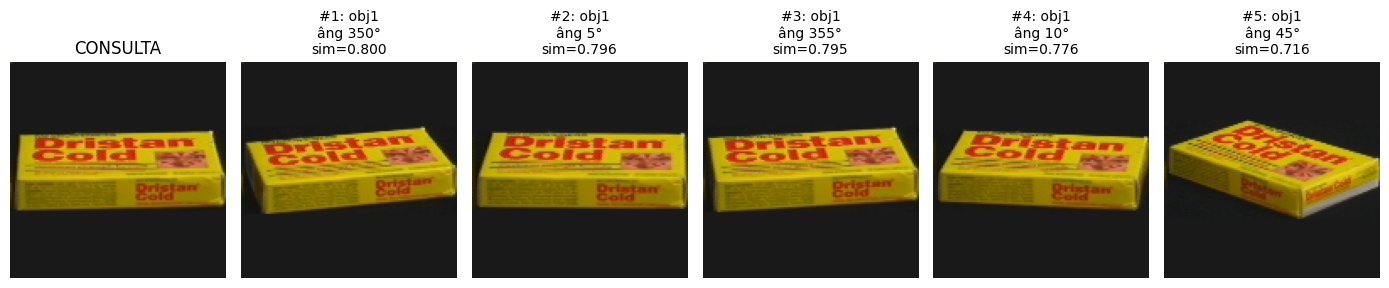


Top-5 resultados mais similares:
  1. obj1__350.png             - similaridade: 0.8004 ✓ MESMO OBJETO
  2. obj1__5.png               - similaridade: 0.7957 ✓ MESMO OBJETO
  3. obj1__355.png             - similaridade: 0.7952 ✓ MESMO OBJETO
  4. obj1__10.png              - similaridade: 0.7759 ✓ MESMO OBJETO
  5. obj1__45.png              - similaridade: 0.7164 ✓ MESMO OBJETO

Consulta: obj10__0.png


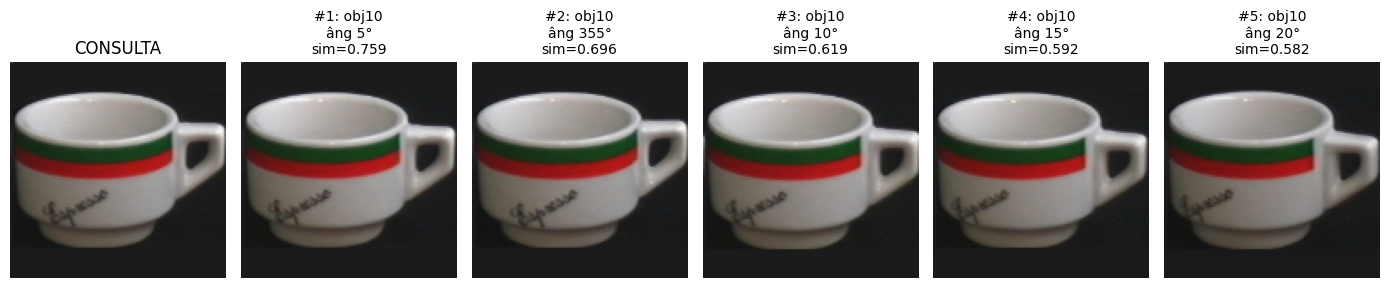


Top-5 resultados mais similares:
  1. obj10__5.png              - similaridade: 0.7593 ✓ MESMO OBJETO
  2. obj10__355.png            - similaridade: 0.6957 ✓ MESMO OBJETO
  3. obj10__10.png             - similaridade: 0.6188 ✓ MESMO OBJETO
  4. obj10__15.png             - similaridade: 0.5921 ✓ MESMO OBJETO
  5. obj10__20.png             - similaridade: 0.5816 ✓ MESMO OBJETO

Consulta: obj100__0.png


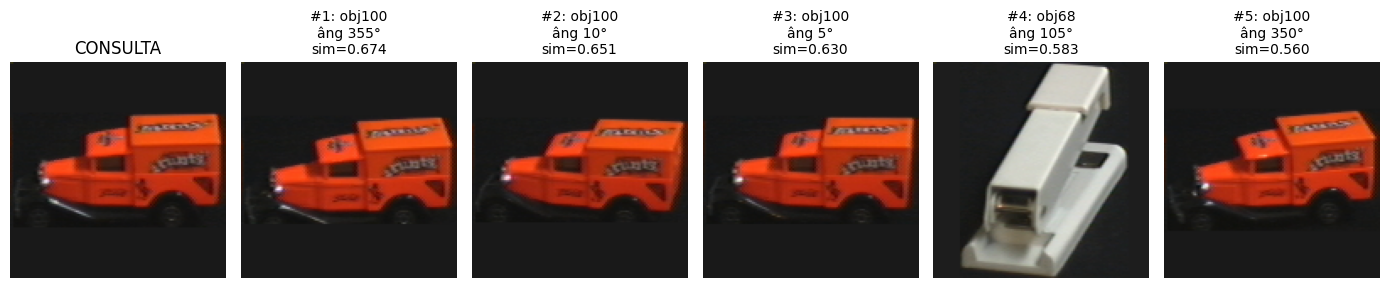


Top-5 resultados mais similares:
  1. obj100__355.png           - similaridade: 0.6740 ✓ MESMO OBJETO
  2. obj100__10.png            - similaridade: 0.6508 ✓ MESMO OBJETO
  3. obj100__5.png             - similaridade: 0.6301 ✓ MESMO OBJETO
  4. obj68__105.png            - similaridade: 0.5826 ✗ OUTRO OBJETO
  5. obj100__350.png           - similaridade: 0.5597 ✓ MESMO OBJETO

Consulta: obj11__0.png


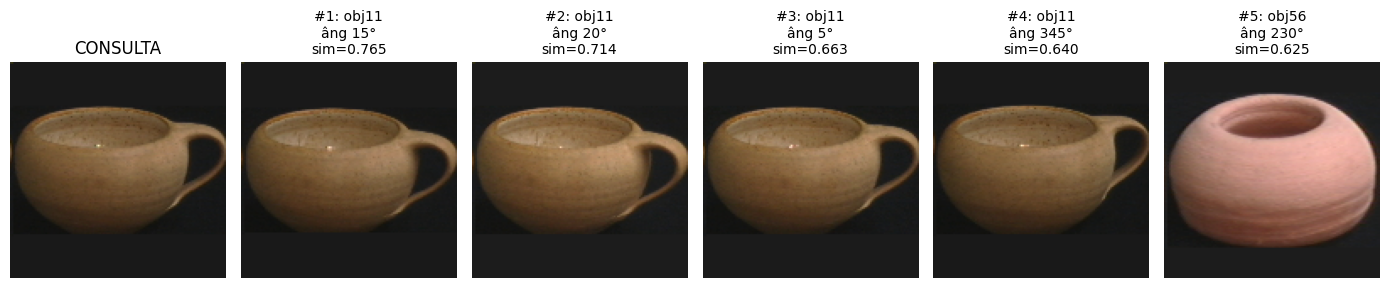


Top-5 resultados mais similares:
  1. obj11__15.png             - similaridade: 0.7655 ✓ MESMO OBJETO
  2. obj11__20.png             - similaridade: 0.7144 ✓ MESMO OBJETO
  3. obj11__5.png              - similaridade: 0.6629 ✓ MESMO OBJETO
  4. obj11__345.png            - similaridade: 0.6396 ✓ MESMO OBJETO
  5. obj56__230.png            - similaridade: 0.6250 ✗ OUTRO OBJETO

Consulta: obj12__0.png


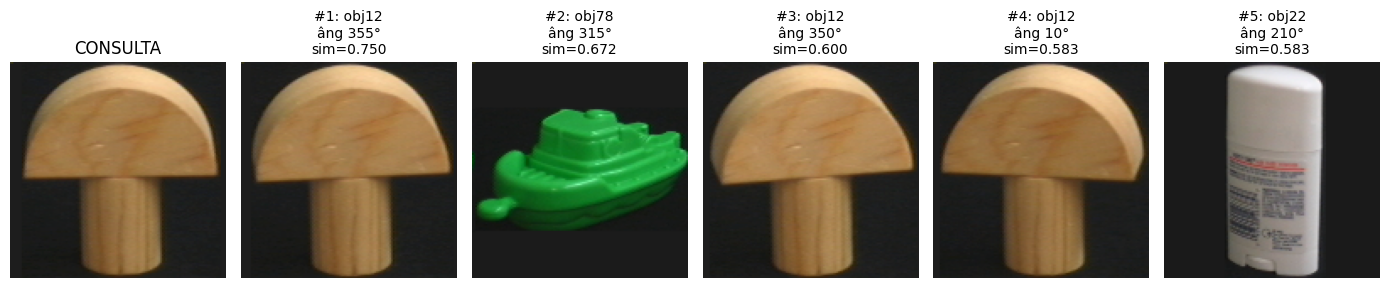


Top-5 resultados mais similares:
  1. obj12__355.png            - similaridade: 0.7500 ✓ MESMO OBJETO
  2. obj78__315.png            - similaridade: 0.6719 ✗ OUTRO OBJETO
  3. obj12__350.png            - similaridade: 0.6000 ✓ MESMO OBJETO
  4. obj12__10.png             - similaridade: 0.5833 ✓ MESMO OBJETO
  5. obj22__210.png            - similaridade: 0.5833 ✗ OUTRO OBJETO

Consulta: obj13__0.png


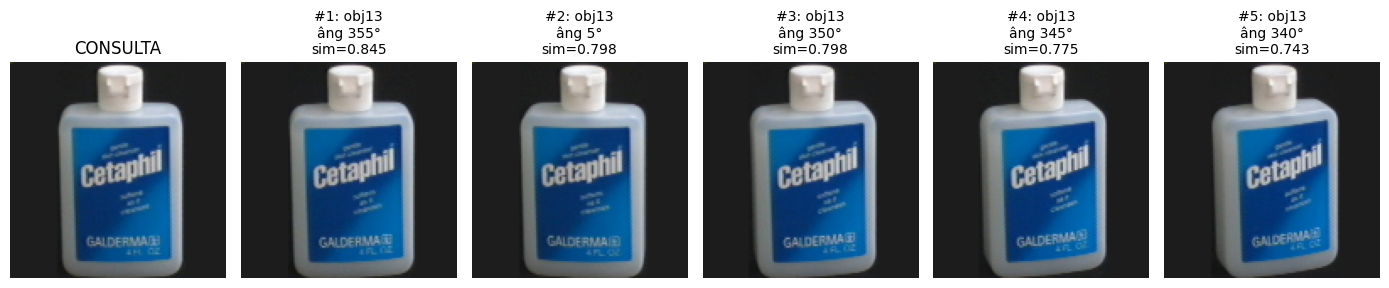


Top-5 resultados mais similares:
  1. obj13__355.png            - similaridade: 0.8454 ✓ MESMO OBJETO
  2. obj13__5.png              - similaridade: 0.7985 ✓ MESMO OBJETO
  3. obj13__350.png            - similaridade: 0.7977 ✓ MESMO OBJETO
  4. obj13__345.png            - similaridade: 0.7751 ✓ MESMO OBJETO
  5. obj13__340.png            - similaridade: 0.7434 ✓ MESMO OBJETO

Consulta: obj14__0.png


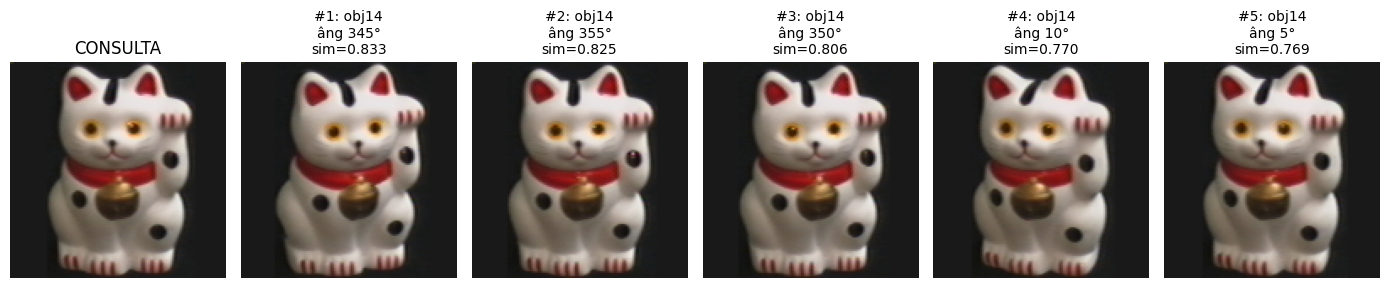


Top-5 resultados mais similares:
  1. obj14__345.png            - similaridade: 0.8329 ✓ MESMO OBJETO
  2. obj14__355.png            - similaridade: 0.8252 ✓ MESMO OBJETO
  3. obj14__350.png            - similaridade: 0.8059 ✓ MESMO OBJETO
  4. obj14__10.png             - similaridade: 0.7704 ✓ MESMO OBJETO
  5. obj14__5.png              - similaridade: 0.7688 ✓ MESMO OBJETO

Consulta: obj15__0.png


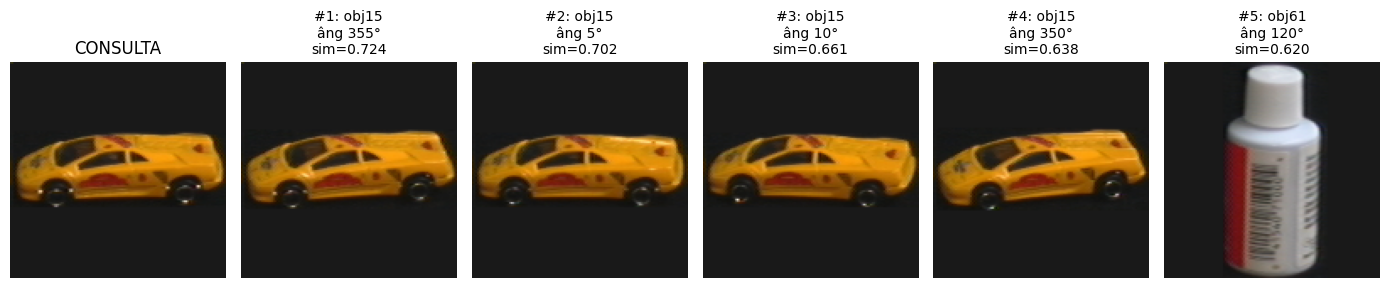


Top-5 resultados mais similares:
  1. obj15__355.png            - similaridade: 0.7239 ✓ MESMO OBJETO
  2. obj15__5.png              - similaridade: 0.7020 ✓ MESMO OBJETO
  3. obj15__10.png             - similaridade: 0.6611 ✓ MESMO OBJETO
  4. obj15__350.png            - similaridade: 0.6381 ✓ MESMO OBJETO
  5. obj61__120.png            - similaridade: 0.6202 ✗ OUTRO OBJETO

Consulta: obj16__0.png


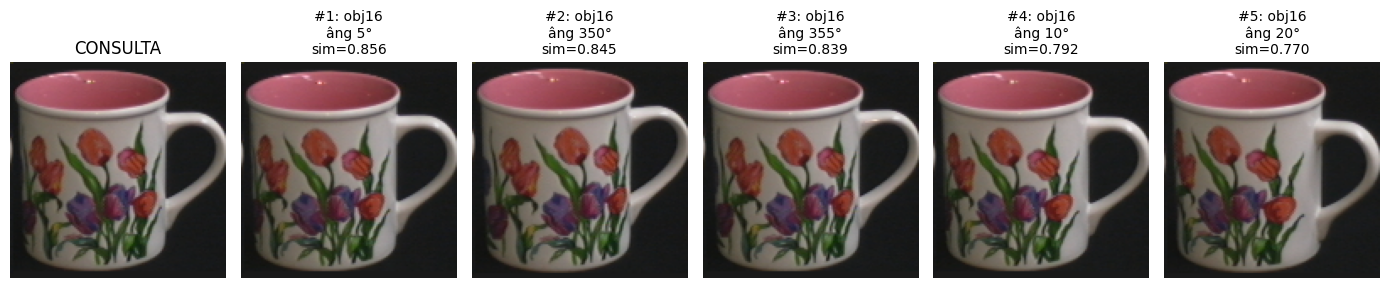


Top-5 resultados mais similares:
  1. obj16__5.png              - similaridade: 0.8557 ✓ MESMO OBJETO
  2. obj16__350.png            - similaridade: 0.8453 ✓ MESMO OBJETO
  3. obj16__355.png            - similaridade: 0.8394 ✓ MESMO OBJETO
  4. obj16__10.png             - similaridade: 0.7921 ✓ MESMO OBJETO
  5. obj16__20.png             - similaridade: 0.7698 ✓ MESMO OBJETO

DEMONSTRAÇÃO CONCLUÍDA


In [13]:
# EXECUTAR CONSULTAS DE TESTE

print("\n" + "="*60)
print("EXECUTANDO CONSULTAS DE TESTE")
print("="*60)

# # Testar com um único objeto primeiro
# consulta(obj='obj1', total_consultas=5, figsize=(14, 5))

# Testar com mais alguns objetos (opcional)
for obj in objs[0:9]:  # obj1, obj2, obj3, obj4, ...,  obj9, obj10
    consulta(obj=obj, total_consultas=5, figsize=(14, 5))

print("\n" + "="*60)
print("DEMONSTRAÇÃO CONCLUÍDA")
print("="*60)